# 📝 Práctica M06: Diagnóstico Visual de una Cartera de Crédito

**Escenario:** El Comité de Riesgos te ha entregado un dataset histórico de clientes. Quieren un informe visual rápido para entender qué caracteriza a los clientes que entran en impago (Default) y si existen patrones extraños en la red de sucursales.

**Ejercicio 0:** Ejecuta esta celda para generar el dataset de 500 clientes con el que realizarás el análisis.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Generación de datos sintéticos
n = 500
ingresos = np.random.gamma(2, 1500, n)
score = np.random.normal(650, 100, n).clip(300, 850)
antiguedad_empleo = np.random.randint(0, 40, n)
sucursal = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], n)

# El Default depende del Score y del Ingreso (lógica simplificada)
prob_default = 1 / (1 + np.exp(-( (600 - score)/50 + (2000 - ingresos)/1000 )))
default = np.random.binomial(1, prob_default)

df_eda = pd.DataFrame({
    'Ingresos': ingresos,
    'Score_Buro': score,
    'Antiguedad_Empleo': antiguedad_empleo,
    'Sucursal': sucursal,
    'Default': default
})  
df_eda

,Ingresos,Score_Buro,Antiguedad_Empleo,Sucursal,Default
0,3590.519085,829.455786,17,Este,0
1,2241.697095,719.476103,39,Oeste,0
2,2073.425377,543.917320,34,Oeste,1
3,2073.453441,301.919117,28,Oeste,1
4,6974.571618,562.977676,28,Este,0
...,...,...,...,...,...
495,3095.440741,550.589377,32,Este,1
496,3205.213451,646.906100,19,Sur,0
497,2172.759913,453.984199,15,Sur,1
498,1250.850695,850.000000,33,Este,0


In [10]:
# Configuración estética
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

## 🛠️ EJERCICIOS

**Ejercicio 1: El Perfil del Cliente (Distribución)**

Crea un gráfico que combine un Histograma y una curva de densidad (KDE) para la variable Score_Buro.

**Pregunta**: ¿Sigue los datos una distribución aproximadamente normal? ¿En qué rango se concentra la mayoría de los clientes?

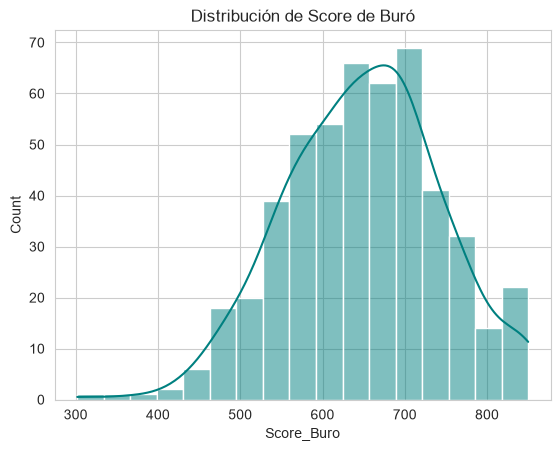

In [14]:
sns.histplot(df_eda['Score_Buro'], kde = True, color = 'teal')
plt.title('Distribución de Score de Buró')
plt.show()

Parece seguir una distribución clásica normal formando una 'campana de Gauss' (simétrica con un pico central y colas que se extienden hacia los lados).
Esto se debe a que la variable ha sido generada con 'np.random.normal()' que fuerza los datos a seguir una distribución normal con una media y desviación específicas.
Según una regla empírica de la normal el 68% de los datos se concentran a una desviación estándar de distancia de la media. Si la de los datos fue 650 y una desviación estándar de 100, la gran mayoría de volúmen  se encuentra en el intervalo [650-100, 650+100] es decir entre los scores 550 y 750.

**Ejercicio 2: Segmentación del Riesgo (Boxplot)**

Crea un Boxplot donde el eje X sea la variable Default (0 o 1) y el eje Y sea el Score_Buro.

**Pregunta:** Comparando las cajas, ¿el Score es una variable que discrimine bien entre buenos y malos pagadores? ¿Ves muchos outliers en el grupo de Default?

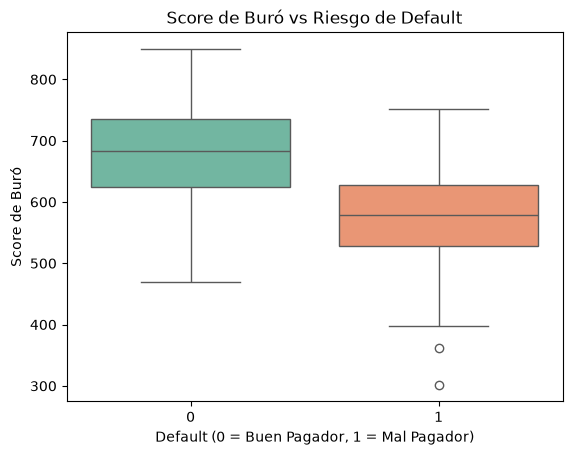

In [10]:
sns.boxplot(data = df_eda, x = 'Default', y = 'Score_Buro', hue = 'Default', palette = 'Set2', legend = False)
plt.title('Score de Buró vs Riesgo de Default')
plt.xlabel('Default (0 = Buen Pagador, 1 = Mal Pagador)')
plt.ylabel('Score de Buró')
plt.show()

Observamos diferencias notables entre medianas, lo que indica que discrimina correctamente. Observamos también que el IQR (rango intercuartílico) que representa el 50% más central de nuestros datos muestra que verticalmente nuestras cajas no se solapan por lo tanto tiene alto poder predictivo nuestra variable, lo que indica que un score bajo tiene alta relación con los impagos.
Observamos outliers extremos dentro de los malos pagadores los cuales tienen 'scores' muy por debajo de la media y, al no observar 'outliers' por encima del boxplot de los malos pagadores nos indica que no existen personas con buenos scores que sean malos pagadores lo que se traduce en que nuestro 'score' es una buena medida del riesgo de impagos

**Ejercicio 3: Análisis Regional (Countplot)**

Representa mediante un gráfico de barras (countplot) la cantidad de clientes por cada Sucursal, pero desglosando por el estado de Default (usa el parámetro hue).

**Pregunta:** ¿Hay alguna sucursal que visualmente parezca tener una proporción de impagos mayor que las demás?

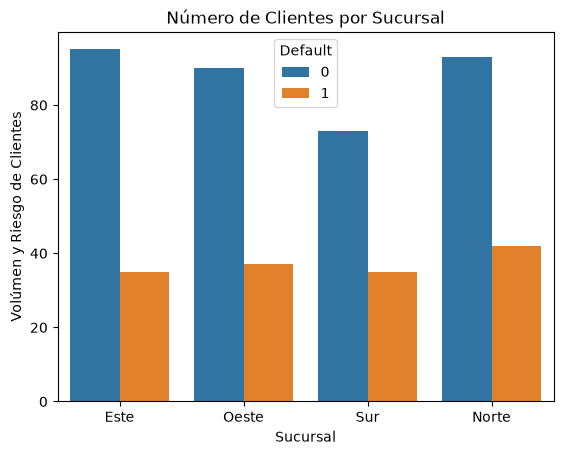

In [17]:
sns.countplot(data = df_eda, x = 'Sucursal', hue = 'Default')
plt.title('Número de Clientes por Sucursal')
plt.ylabel('Volúmen y Riesgo de Clientes')
plt.show()



La sucursal Sur presenta mayor porcentaje de impagos, puesto que a pesar de que el número de impagos es similar en todas las sucursales (un poco superior en la Norte), la sucursal Sur acumula el menor número de buenos pagadores (Default=1) pero mantiene esa media de malos pagadores, lo que visualmente observamos pues la diferencia entre la barra azul y naranja en la sucursal Sur es la menor de todas. 

**Ejercicio 4: Relaciones Multivariante (Scatter Plot)**

Crea un Scatter Plot que relacione Ingresos (Eje X) con Antiguedad_Empleo (Eje Y). Utiliza el color (hue) para diferenciar por Default.

**Pregunta:** ¿Ves algún "clúster" o zona del gráfico donde se concentren los puntos de Default?

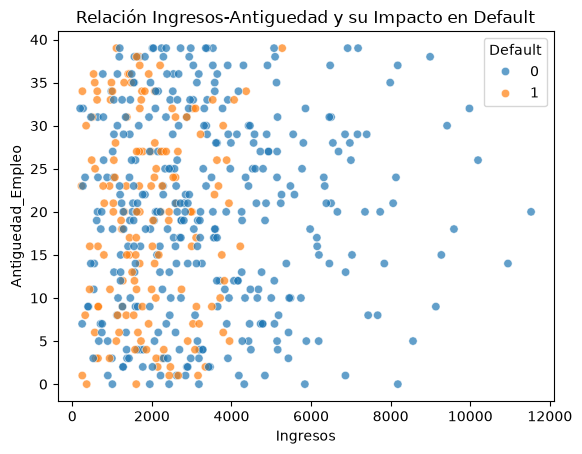

In [ ]:
sns.scatterplot(data = df_eda, x = 'Ingresos', y = 'Antiguedad_Empleo', hue = 'Default', alpha = 0.7)
#'alpha' le da opacidad a los puntos para evitar el 'overplotting'
plt.title('Relación Ingresos-Antiguedad y su Impacto en Default')
plt.show()

Los puntos de 'Default' se sitúan en la parte izquierda del gráfico lo que, nos permite observar de un vistazo que, cuando los ingresos son más bajos, el riesgo de impagos aumenta de forma notable. Si observamos la relación que este cluster tiene con la antiguedad en la empresa podemos determinar que no tienen ninguna relación pues los 'default' se distribuyen de manera uniforme a lo largo del eje, lo que no indica ningún patronaje que nos permita relacionar las variables e indica que la antiguedad no tendría poder predictivo sobre el riesgo de impagos.

**Ejercicio 5: Mapa de Correlación**

Calcula la matriz de correlación del dataframe y represéntala con un Heatmap. Asegúrate de mostrar los números dentro de los cuadros (annot=True).

**Pregunta:** ¿Qué variable numérica tiene la correlación más fuerte con el Default?

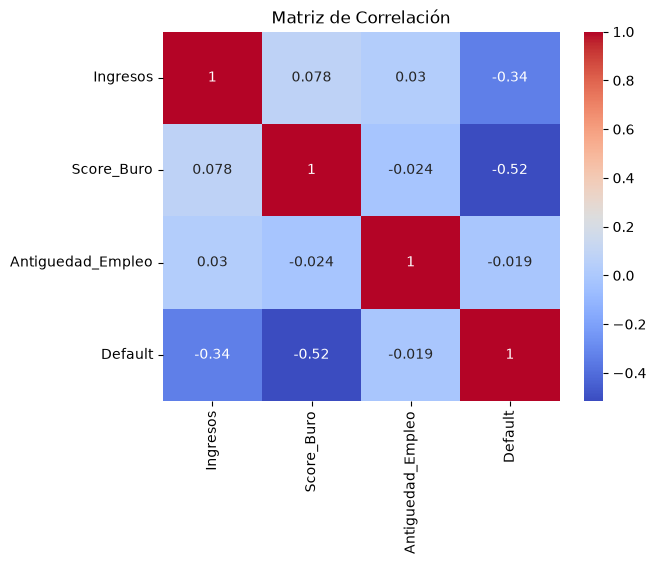

In [32]:
sns.heatmap(df_eda.corr(numeric_only=True), annot = True, cmap = 'coolwarm')
#sns.heatmap(df_eda.drop('Sucursal', axis = 1).corr(), annot = True, cmap = 'coolwarm')
#Podríamos hacerlo eliminando la columna que sabemos que es de texto 
#o simplemente si no conocemos el df al completo decirle que se fije únicamente en las columnas numéricas
plt.title('Matriz de Correlación')
plt.show()

Observamos que, la antiguedad en el empleo como habíamos interpretado anteriormente no tiene relación lineal con 'default' pero, podemos identificar que tanto ingresos como el score tienen una relación inversamente proporcional con 'default' de donde obtenemos que el 'Score_Buró' es la variable numérica con la correlación más fuerte con 'default'

## ✅ SOLUCIONES

In [ ]:
# Configuración estética
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))

# 1. Distribución del Score
sns.histplot(df_eda['Score_Buro'], kde=True, color='teal')
plt.title('Distribución de Score de Buró')
plt.show()

# 2. Boxplot Discriminante
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_eda, x='Default', y='Score_Buro', palette='Set2')
plt.title('Score vs Default (Capacidad de Discriminación)')
plt.show()

# 3. Análisis de Sucursales
plt.figure(figsize=(10, 6))
sns.countplot(data=df_eda, x='Sucursal', hue='Default')
plt.title('Volumen y Riesgo por Sucursal')
plt.show()

# 4. Relación Ingresos vs Antigüedad
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_eda, x='Ingresos', y='Antiguedad_Empleo', hue='Default', alpha=0.7)
plt.title('Relación Ingresos-Antigüedad y su impacto en Default')
plt.show()

# 5. Mapa de Calor
plt.figure(figsize=(8, 6))
sns.heatmap(df_eda.drop('Sucursal', axis = 1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()